In [1]:
import pandas as pd
import numpy as np
import joblib
import time

from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
X_train = joblib.load("../models/X_train_processed.joblib")
X_test = joblib.load("../models/X_test_processed.joblib")

y_train = joblib.load("../models/y_train.joblib")
y_test = joblib.load("../models/y_test.joblib")

print("Prepared data loaded successfully")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Prepared data loaded successfully
X_train: (41413, 112)
X_test : (10354, 112)
y_train: (41413,)
y_test : (10354,)


In [3]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation created successfully")

5-Fold Cross-Validation created successfully


In [4]:
ridge_cv = Ridge(alpha=1.0)

ridge_scores = cross_val_score(
    ridge_cv,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("Ridge Cross-Validation R² Scores:")
print(ridge_scores)

print("\nMean R²:", ridge_scores.mean())
print("Standard Deviation:", ridge_scores.std())

Ridge Cross-Validation R² Scores:
[0.72374169 0.69298219 0.41416104 0.68929599 0.67743484]

Mean R²: 0.6395231511295192
Standard Deviation: 0.11371309882021821


In [5]:
lasso_cv = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso_scores = cross_val_score(
    lasso_cv,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("Lasso Cross-Validation R² Scores:")
print(lasso_scores)

print("\nMean R²:", lasso_scores.mean())
print("Standard Deviation:", lasso_scores.std())

Lasso Cross-Validation R² Scores:
[0.72348722 0.69309744 0.41508075 0.68928928 0.67795748]

Mean R²: 0.6397824334746589
Standard Deviation: 0.11335615693119394


In [6]:
rf_cv = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_scores = cross_val_score(
    rf_cv,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

end_time = time.time()

print("Random Forest Cross-Validation R² Scores:")
print(rf_scores)

print("\nMean R²:", rf_scores.mean())
print("Standard Deviation:", rf_scores.std())

print("\nTime taken:", round(end_time - start_time, 2), "seconds")

Random Forest Cross-Validation R² Scores:
[0.88886828 0.88869612 0.86580175 0.87221319 0.8050719 ]

Mean R²: 0.8641302469345149
Standard Deviation: 0.030891646040502985

Time taken: 227.99 seconds


In [7]:
rf_cv = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_scores = cross_val_score(
    rf_cv,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

end_time = time.time()

print("Random Forest Cross-Validation R² Scores:")
print(rf_scores)

print("\nMean R²:", rf_scores.mean())
print("Standard Deviation:", rf_scores.std())

print("\nTime taken:", round(end_time - start_time, 2), "seconds")

Random Forest Cross-Validation R² Scores:
[0.88886828 0.88869612 0.86580175 0.87221319 0.8050719 ]

Mean R²: 0.8641302469345149
Standard Deviation: 0.030891646040502985

Time taken: 231.91 seconds


In [8]:
gb_cv = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

start_time = time.time()

gb_scores = cross_val_score(
    gb_cv,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

end_time = time.time()

print("Gradient Boosting Cross-Validation R² Scores:")
print(gb_scores)

print("\nMean R²:", gb_scores.mean())
print("Standard Deviation:", gb_scores.std())

print("\nTime taken:", round(end_time - start_time, 2), "seconds")

Gradient Boosting Cross-Validation R² Scores:
[0.84395124 0.8428367  0.80130194 0.8379938  0.78223037]

Mean R²: 0.8216628111632145
Standard Deviation: 0.025224162130888225

Time taken: 7.83 seconds


In [9]:
cv_results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean R2": [
        ridge_scores.mean(),
        lasso_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean()
    ],
    "Std R2": [
        ridge_scores.std(),
        lasso_scores.std(),
        rf_scores.std(),
        gb_scores.std()
    ]
})

cv_results

,Model,Mean R2,Std R2
0,Ridge Regression,0.639523,0.113713
1,Lasso Regression,0.639782,0.113356
2,Random Forest,0.864130,0.030892
3,Gradient Boosting,0.821663,0.025224


In [10]:
cv_results_sorted = cv_results.sort_values(
    by="Mean R2",
    ascending=False
).reset_index(drop=True)

cv_results_sorted

,Model,Mean R2,Std R2
0,Random Forest,0.864130,0.030892
1,Gradient Boosting,0.821663,0.025224
2,Lasso Regression,0.639782,0.113356
3,Ridge Regression,0.639523,0.113713


In [12]:
ridge_param_grid = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

print(ridge_param_grid)

{'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}


In [13]:
ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()

ridge_grid.fit(
    X_train,
    y_train
)

end_time = time.time()

print("Ridge tuning completed")
print("Time taken:", round(end_time - start_time, 2), "seconds")

Ridge tuning completed
Time taken: 2.97 seconds


In [15]:
print("Best Ridge parameters:")
print(ridge_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(ridge_grid.best_score_)

Best Ridge parameters:
{'alpha': 1.0}

Best Cross-Validation R²:
0.632974417679713


In [16]:
lasso_param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

print(lasso_param_grid)

{'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}


In [17]:
lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()

lasso_grid.fit(
    X_train,
    y_train
)

end_time = time.time()

print("Lasso tuning completed")
print("Time taken:", round(end_time - start_time, 2), "seconds")

Lasso tuning completed
Time taken: 193.42 seconds


c:\Users\Tejas Dalvi\anaconda3\anaconda\envs\mumbai-house\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.032044e+18, tolerance: 5.255e+15
  model = cd_fast.sparse_enet_coordinate_descent(


In [18]:
print("Best Lasso parameters:")
print(lasso_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(lasso_grid.best_score_)

Best Lasso parameters:
{'alpha': 0.0001}

Best Cross-Validation R²:
0.6327477115872296


In [19]:
ridge_param_grid = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

print(ridge_param_grid)

{'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}


In [22]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5]
}

print(rf_param_grid)

{'n_estimators': [100, 200], 'max_depth': [None, 15, 25], 'min_samples_split': [2, 5]}


In [23]:
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()

rf_grid.fit(
    X_train,
    y_train
)

end_time = time.time()

print("Random Forest tuning completed")
print("Time taken:", round(end_time - start_time, 2), "seconds")

Random Forest tuning completed
Time taken: 1123.99 seconds


In [24]:
print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(rf_grid.best_score_)

Best Random Forest parameters:
{'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation R²:
0.8496974253961399


In [25]:
gb_param_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3]
}

print(gb_param_grid)

{'n_estimators': [100, 150], 'learning_rate': [0.03, 0.05, 0.1], 'max_depth': [2, 3]}


In [26]:
gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()

gb_grid.fit(
    X_train,
    y_train
)

end_time = time.time()

print("Gradient Boosting tuning completed")
print("Time taken:", round(end_time - start_time, 2), "seconds")

Gradient Boosting tuning completed
Time taken: 43.02 seconds


In [27]:
gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()

gb_grid.fit(
    X_train,
    y_train
)

end_time = time.time()

print("Gradient Boosting tuning completed")
print("Time taken:", round(end_time - start_time, 2), "seconds")

Gradient Boosting tuning completed
Time taken: 37.38 seconds


In [28]:
gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()

gb_grid.fit(
    X_train,
    y_train
)

end_time = time.time()

print("Gradient Boosting tuning completed")
print("Time taken:", round(end_time - start_time, 2), "seconds")

Gradient Boosting tuning completed
Time taken: 34.7 seconds


In [29]:
print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(gb_grid.best_score_)

Best Gradient Boosting parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}

Best Cross-Validation R²:
0.8441309412081219


In [30]:
def evaluate_tuned_model(model_name, model):
    
    predictions = model.predict(X_test)
    
    mse = mean_squared_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(mse)
    
    r2 = r2_score(
        y_test,
        predictions
    )
    
    return {
        "Model": model_name,
        "R2 Score": r2,
        "MSE": mse,
        "RMSE": rmse
    }


print("Evaluation function created successfully")

Evaluation function created successfully


In [31]:
tuned_ridge_result = evaluate_tuned_model(
    "Tuned Ridge",
    ridge_grid.best_estimator_
)

print(tuned_ridge_result)

{'Model': 'Tuned Ridge', 'R2 Score': 0.6561153346710666, 'MSE': 321754280858711.06, 'RMSE': np.float64(17937510.442051623)}


In [32]:
tuned_lasso_result = evaluate_tuned_model(
    "Tuned Lasso",
    lasso_grid.best_estimator_
)

print(tuned_lasso_result)

{'Model': 'Tuned Lasso', 'R2 Score': 0.6559048772172849, 'MSE': 321951194514713.0, 'RMSE': np.float64(17942998.481711827)}


In [33]:
tuned_rf_result = evaluate_tuned_model(
    "Tuned Random Forest",
    rf_grid.best_estimator_
)

print(tuned_rf_result)

{'Model': 'Tuned Random Forest', 'R2 Score': 0.8186965998367207, 'MSE': 169635784954168.2, 'RMSE': np.float64(13024430.312077692)}


In [34]:
tuned_gb_result = evaluate_tuned_model(
    "Tuned Gradient Boosting",
    gb_grid.best_estimator_
)

print(tuned_gb_result)

{'Model': 'Tuned Gradient Boosting', 'R2 Score': 0.7802526502263392, 'MSE': 205605709197301.06, 'RMSE': np.float64(14338957.744456222)}


In [35]:
tuned_results = [
    tuned_ridge_result,
    tuned_lasso_result,
    tuned_rf_result,
    tuned_gb_result
]

tuned_results_df = pd.DataFrame(
    tuned_results
)

tuned_results_df

,Model,R2 Score,MSE,RMSE
0,Tuned Ridge,0.656115,3.217543e+14,1.793751e+07
1,Tuned Lasso,0.655905,3.219512e+14,1.794300e+07
2,Tuned Random Forest,0.818697,1.696358e+14,1.302443e+07
3,Tuned Gradient Boosting,0.780253,2.056057e+14,1.433896e+07


In [36]:
tuned_results_by_r2 = tuned_results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

tuned_results_by_r2

,Model,R2 Score,MSE,RMSE
0,Tuned Random Forest,0.818697,1.696358e+14,1.302443e+07
1,Tuned Gradient Boosting,0.780253,2.056057e+14,1.433896e+07
2,Tuned Ridge,0.656115,3.217543e+14,1.793751e+07
3,Tuned Lasso,0.655905,3.219512e+14,1.794300e+07


In [37]:
tuned_results_by_rmse = tuned_results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

tuned_results_by_rmse

,Model,R2 Score,MSE,RMSE
0,Tuned Random Forest,0.818697,1.696358e+14,1.302443e+07
1,Tuned Gradient Boosting,0.780253,2.056057e+14,1.433896e+07
2,Tuned Ridge,0.656115,3.217543e+14,1.793751e+07
3,Tuned Lasso,0.655905,3.219512e+14,1.794300e+07


In [38]:
previous_results = pd.read_csv(
    "../models/model_comparison_results.csv"
)

print("Previous model results:")
display(previous_results)

Previous model results:


,Model,R2 Score,MSE,RMSE
0,Linear Regression,0.655707,3.221367e+14,1.794817e+07
1,Ridge Regression,0.656115,3.217543e+14,1.793751e+07
2,Lasso Regression,0.655905,3.219512e+14,1.794300e+07
3,Random Forest,0.815132,1.729709e+14,1.315184e+07
4,Gradient Boosting,0.772086,2.132463e+14,1.460296e+07
5,Log Linear Regression,0.487106,4.798872e+14,2.190633e+07
6,Log Ridge Regression,0.484468,4.823556e+14,2.196260e+07
7,Log Random Forest,0.838262,1.513292e+14,1.230159e+07
8,Log Gradient Boosting,0.775539,2.100162e+14,1.449194e+07


In [39]:
comparison_before_after = pd.DataFrame({
    "Model": [
        "Ridge",
        "Lasso",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Before Tuning R2": [
        previous_results.loc[
            previous_results["Model"] == "Ridge Regression",
            "R2 Score"
        ].iloc[0],
        
        previous_results.loc[
            previous_results["Model"] == "Lasso Regression",
            "R2 Score"
        ].iloc[0],
        
        previous_results.loc[
            previous_results["Model"] == "Random Forest",
            "R2 Score"
        ].iloc[0],
        
        previous_results.loc[
            previous_results["Model"] == "Gradient Boosting",
            "R2 Score"
        ].iloc[0]
    ],
    
    "After Tuning R2": [
        tuned_ridge_result["R2 Score"],
        tuned_lasso_result["R2 Score"],
        tuned_rf_result["R2 Score"],
        tuned_gb_result["R2 Score"]
    ]
})

comparison_before_after

,Model,Before Tuning R2,After Tuning R2
0,Ridge,0.656115,0.656115
1,Lasso,0.655905,0.655905
2,Random Forest,0.815132,0.818697
3,Gradient Boosting,0.772086,0.780253


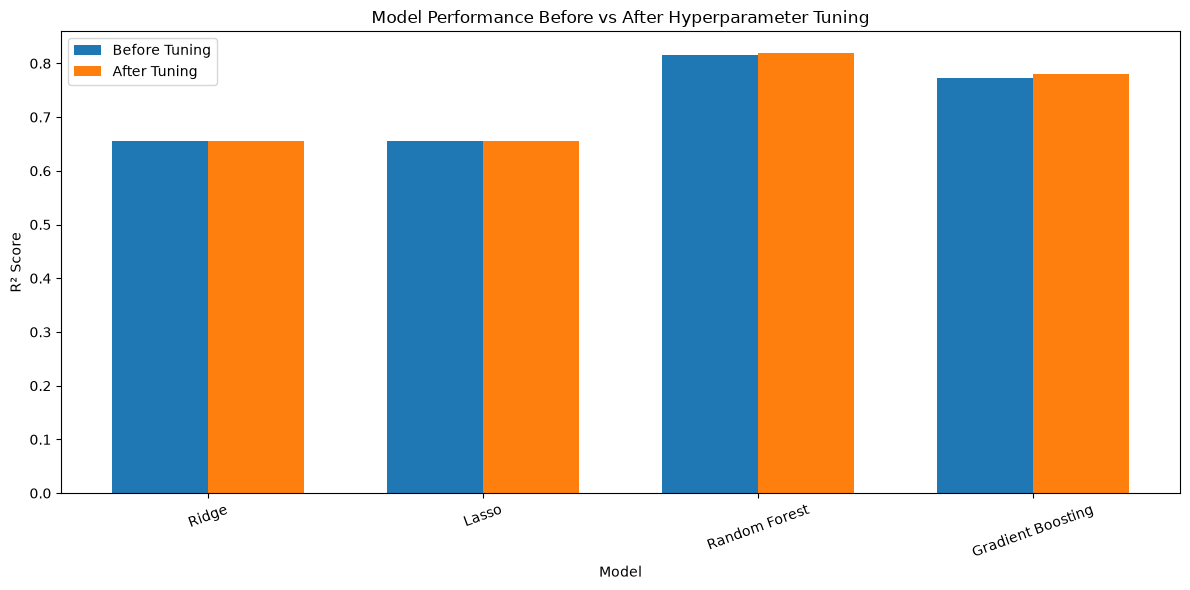

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure R2 values are numeric
comparison_before_after["Before Tuning R2"] = pd.to_numeric(
    comparison_before_after["Before Tuning R2"],
    errors="coerce"
)

comparison_before_after["After Tuning R2"] = pd.to_numeric(
    comparison_before_after["After Tuning R2"],
    errors="coerce"
)

# Remove rows with missing R2 values
plot_data = comparison_before_after.dropna(
    subset=["Before Tuning R2", "After Tuning R2"]
).copy()

# Create positions
x = np.arange(len(plot_data))
width = 0.35

# Create figure
plt.figure(figsize=(12, 6))

# Before tuning
plt.bar(
    x - width / 2,
    plot_data["Before Tuning R2"].values,
    width,
    label="Before Tuning"
)

# After tuning
plt.bar(
    x + width / 2,
    plot_data["After Tuning R2"].values,
    width,
    label="After Tuning"
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Before vs After Hyperparameter Tuning")

plt.xticks(
    x,
    plot_data["Model"].values,
    rotation=20
)

plt.legend()
plt.tight_layout()
plt.show()

In [44]:
best_tuned_row = tuned_results_by_r2.iloc[0]

best_tuned_name = best_tuned_row["Model"]
best_tuned_r2 = best_tuned_row["R2 Score"]
best_tuned_rmse = best_tuned_row["RMSE"]

print("Best tuned model according to test-set R²:")
print(best_tuned_name)

print("\nR² Score:", best_tuned_r2)
print("RMSE:", best_tuned_rmse)

Best tuned model according to test-set R²:
Tuned Random Forest

R² Score: 0.8186965998367207
RMSE: 13024430.312077692


In [45]:
tuned_model_objects = {
    "Tuned Ridge": ridge_grid.best_estimator_,
    "Tuned Lasso": lasso_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

best_tuned_model = tuned_model_objects[best_tuned_name]

print("Best tuned model object selected:")
print(best_tuned_model)

Best tuned model object selected:
RandomForestRegressor(max_depth=25, n_jobs=-1, random_state=42)


In [46]:
joblib.dump(
    best_tuned_model,
    "../models/best_tuned_model.joblib"
)

print("Best tuned model saved successfully")

Best tuned model saved successfully


In [47]:
tuned_results_df.to_csv(
    "../models/tuned_model_results.csv",
    index=False
)

print("Tuned model results saved successfully")

Tuned model results saved successfully


In [48]:
best_model_info = {
    "model_name": best_tuned_name,
    "r2_score": best_tuned_r2,
    "rmse": best_tuned_rmse
}

joblib.dump(
    best_model_info,
    "../models/best_model_info.joblib"
)

print("Best model information saved successfully")

Best model information saved successfully


In [49]:
import os

files_to_check = [
    "../models/best_tuned_model.joblib",
    "../models/tuned_model_results.csv",
    "../models/best_model_info.joblib"
]

print("Checking saved files:\n")

for file in files_to_check:
    
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

Checking saved files:

✓ ../models/best_tuned_model.joblib
✓ ../models/tuned_model_results.csv
✓ ../models/best_model_info.joblib


In [50]:
final_model = joblib.load(
    "../models/best_tuned_model.joblib"
)

print("Final tuned model loaded successfully")
print(final_model)

Final tuned model loaded successfully
RandomForestRegressor(max_depth=25, n_jobs=-1, random_state=42)


In [51]:
final_predictions = final_model.predict(X_test)

final_mse = mean_squared_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(final_mse)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("Final Model Performance")
print("=" * 40)

print("R² Score :", final_r2)
print("MSE      :", final_mse)
print("RMSE     :", final_rmse)

Final Model Performance
R² Score : 0.8186965998367207
MSE      : 169635784954168.2
RMSE     : 13024430.312077692


In [52]:
prediction_check = pd.DataFrame({
    "Actual Price": y_test.iloc[:20].values,
    "Predicted Price": final_predictions[:20]
})

prediction_check

,Actual Price,Predicted Price
0,39500000,3.942119e+07
1,16500000,1.911800e+07
2,75000000,6.627395e+07
3,1851000,2.410896e+06
4,18000000,1.961052e+07
5,8000000,7.239793e+06
6,16000000,1.590222e+07
7,3800000,4.389770e+06
8,15000000,1.706556e+07
9,16957615,1.622203e+07


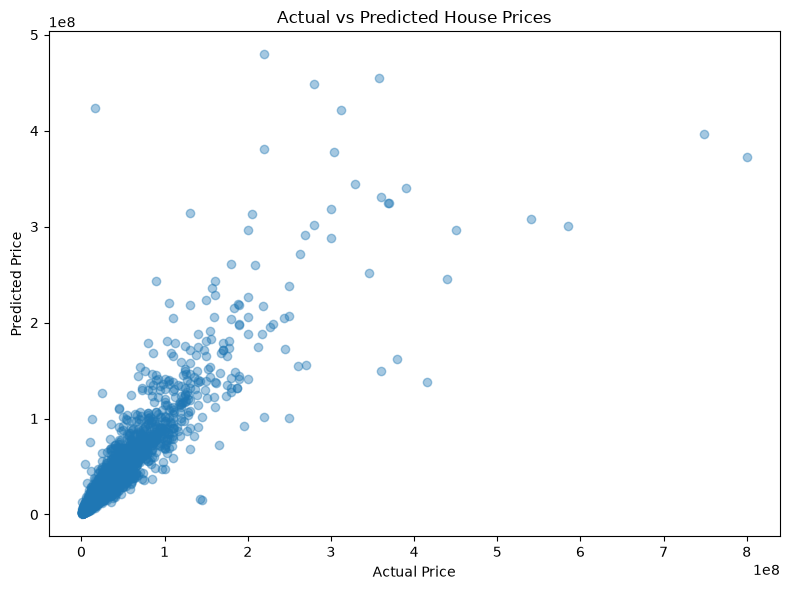

In [53]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.4
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.tight_layout()
plt.show()

In [54]:
print("=" * 70)
print("MODEL TUNING COMPLETED")
print("=" * 70)

print("\nCross-Validation:")
print("- 5-Fold Cross-Validation used for initial model stability check")

print("\nHyperparameter Tuning:")
print("- Ridge Regression")
print("- Lasso Regression")
print("- Random Forest Regression")
print("- Gradient Boosting Regression")

print("\nEvaluation Metrics:")
print("- R² Score")
print("- Mean Squared Error")
print("- Root Mean Squared Error")

print("\nFinal Tuned Model:")
print(best_tuned_name)

print("\nFinal R² Score:")
print(final_r2)

print("\nFinal RMSE:")
print(final_rmse)

print("\nSaved:")
print("- best_tuned_model.joblib")
print("- tuned_model_results.csv")
print("- best_model_info.joblib")

print("\nModel tuning stage completed successfully.")

MODEL TUNING COMPLETED

Cross-Validation:
- 5-Fold Cross-Validation used for initial model stability check

Hyperparameter Tuning:
- Ridge Regression
- Lasso Regression
- Random Forest Regression
- Gradient Boosting Regression

Evaluation Metrics:
- R² Score
- Mean Squared Error
- Root Mean Squared Error

Final Tuned Model:
Tuned Random Forest

Final R² Score:
0.8186965998367207

Final RMSE:
13024430.312077692

Saved:
- best_tuned_model.joblib
- tuned_model_results.csv
- best_model_info.joblib

Model tuning stage completed successfully.


In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import joblib
import os
import time

print("=" * 70)
print("RENDER OPTIMIZED RANDOM FOREST")
print("=" * 70)

# Smaller production model
render_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=25,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

print("\nModel configuration:")
print("n_estimators     :", 30)
print("max_depth        :", 25)
print("min_samples_split:", 2)
print("features         :", X_train.shape[1])

# Train
start_time = time.time()

render_model.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print("\nTraining completed.")
print("Training time:", round(training_time, 2), "seconds")

# Test prediction
render_predictions = render_model.predict(X_test)

# Metrics
render_mse = mean_squared_error(
    y_test,
    render_predictions
)

render_rmse = np.sqrt(render_mse)

render_r2 = r2_score(
    y_test,
    render_predictions
)

print("\n" + "=" * 70)
print("RENDER MODEL PERFORMANCE")
print("=" * 70)

print("R² Score :", render_r2)
print("MSE      :", render_mse)
print("RMSE     :", render_rmse)

# Compare with current best model
print("\n" + "=" * 70)
print("COMPARISON WITH CURRENT BEST MODEL")
print("=" * 70)

print("Current Best R² :", best_tuned_r2)
print("Render Model R² :", render_r2)

print("Current Best RMSE :", best_tuned_rmse)
print("Render Model RMSE :", render_rmse)

r2_difference = best_tuned_r2 - render_r2
rmse_difference = render_rmse - best_tuned_rmse

print("\nR² difference :", r2_difference)
print("RMSE difference:", rmse_difference)

# Save only the new model
render_model_path = "../models/render_optimized_model.joblib"

joblib.dump(
    render_model,
    render_model_path,
    compress=3
)

print("\nRender optimized model saved:")
print(render_model_path)

# Check file size
if os.path.exists(render_model_path):
    size_mb = os.path.getsize(render_model_path) / (1024 * 1024)

    print("Model file size:", round(size_mb, 2), "MB")

print("\nRender optimized model creation completed.")

RENDER OPTIMIZED RANDOM FOREST

Model configuration:
n_estimators     : 30
max_depth        : 25
min_samples_split: 2


NameError: name 'X_train' is not defined

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=" * 70)
print("LOADING TRAINING DATA")
print("=" * 70)

# Load processed train/test data
X_train = joblib.load("../models/X_train_processed.joblib")
X_test = joblib.load("../models/X_test_processed.joblib")

y_train = joblib.load("../models/y_train.joblib")
y_test = joblib.load("../models/y_test.joblib")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nData loaded successfully.")


# ============================================================
# RENDER OPTIMIZED MODEL
# ============================================================

print("\n" + "=" * 70)
print("CREATING RENDER OPTIMIZED RANDOM FOREST")
print("=" * 70)

render_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=25,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

print("\nModel configuration:")
print("n_estimators      :", 30)
print("max_depth         :", 25)
print("min_samples_split :", 2)
print("features          :", X_train.shape[1])


# ============================================================
# TRAIN
# ============================================================

print("\nTraining model...")

start_time = time.time()

render_model.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print("\nTraining completed.")
print("Training time:", round(training_time, 2), "seconds")


# ============================================================
# PREDICTION
# ============================================================

render_predictions = render_model.predict(
    X_test
)


# ============================================================
# PERFORMANCE
# ============================================================

render_mse = mean_squared_error(
    y_test,
    render_predictions
)

render_rmse = np.sqrt(
    render_mse
)

render_r2 = r2_score(
    y_test,
    render_predictions
)


print("\n" + "=" * 70)
print("RENDER MODEL PERFORMANCE")
print("=" * 70)

print("R² Score :", render_r2)
print("MSE      :", render_mse)
print("RMSE     :", render_rmse)


# ============================================================
# SAVE MODEL
# ============================================================

render_model_path = "../models/render_optimized_model.joblib"

joblib.dump(
    render_model,
    render_model_path,
    compress=3
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print("Path:", render_model_path)


# ============================================================
# FILE SIZE
# ============================================================

if os.path.exists(render_model_path):

    size_mb = (
        os.path.getsize(render_model_path)
        / (1024 * 1024)
    )

    print(
        "Model file size:",
        round(size_mb, 2),
        "MB"
    )


# ============================================================
# BASIC VERIFICATION
# ============================================================

print("\n" + "=" * 70)
print("MODEL VERIFICATION")
print("=" * 70)

print("Model type:", type(render_model))
print(
    "Estimators:",
    len(render_model.estimators_)
)

print(
    "Max depth:",
    render_model.max_depth
)

print(
    "Features:",
    render_model.n_features_in_
)

print("\nFirst 5 predictions:")
print(render_predictions[:5])

print("\n" + "=" * 70)
print("RENDER OPTIMIZED MODEL READY")
print("=" * 70)

LOADING TRAINING DATA
X_train: (41413, 112)
X_test : (10354, 112)
y_train: (41413,)
y_test : (10354,)

Data loaded successfully.

CREATING RENDER OPTIMIZED RANDOM FOREST

Model configuration:
n_estimators      : 30
max_depth         : 25
min_samples_split : 2
features          : 112

Training model...

Training completed.
Training time: 17.01 seconds

RENDER MODEL PERFORMANCE
R² Score : 0.8241989239668484
MSE      : 164487557882608.25
RMSE     : 12825270.284972876

MODEL SAVED
Path: ../models/render_optimized_model.joblib
Model file size: 17.74 MB

MODEL VERIFICATION
Model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Estimators: 30
Max depth: 25
Features: 112

First 5 predictions:
[38088518.48518518 19183333.33333333 66786666.66666666  2357664.9
 18971076.78629757]

RENDER OPTIMIZED MODEL READY


In [3]:
import os
import joblib

model_path = "../models/render_optimized_model.joblib"

print("=" * 70)
print("RENDER OPTIMIZED MODEL VERIFICATION")
print("=" * 70)

model = joblib.load(model_path)

print("\nModel type:")
print(type(model))

print("\nModel configuration:")
print("Estimators     :", len(model.estimators_))
print("Max depth      :", model.max_depth)
print("Features       :", model.n_features_in_)

print("\nModel file:")
print("Path           :", model_path)
print("Exists         :", os.path.exists(model_path))

if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print("File size      :", round(size_mb, 2), "MB")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

RENDER OPTIMIZED MODEL VERIFICATION

Model type:
<class 'sklearn.ensemble._forest.RandomForestRegressor'>

Model configuration:
Estimators     : 30
Max depth      : 25
Features       : 112

Model file:
Path           : ../models/render_optimized_model.joblib
Exists         : True
File size      : 17.74 MB

DONE


In [4]:
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Load Render optimized model
render_model = joblib.load("../models/render_optimized_model.joblib")

# Predictions
y_pred_render = render_model.predict(X_test)

# Metrics
render_r2 = r2_score(y_test, y_pred_render)
render_rmse = np.sqrt(mean_squared_error(y_test, y_pred_render))

print("=" * 70)
print("RENDER OPTIMIZED MODEL ACCURACY")
print("=" * 70)

print(f"R² Score : {render_r2:.6f}")
print(f"RMSE     : {render_rmse:.6f}")

print("=" * 70)

RENDER OPTIMIZED MODEL ACCURACY
R² Score : 0.824199
RMSE     : 12825270.284973


In [5]:
import joblib
import numpy as np
import os
from sklearn.metrics import r2_score, mean_squared_error

# Load original model
original_model = joblib.load("../models/best_tuned_model.joblib")

# Load Render optimized model
render_model = joblib.load("../models/render_optimized_model.joblib")

# Predictions
original_pred = original_model.predict(X_test)
render_pred = render_model.predict(X_test)

# Metrics
original_r2 = r2_score(y_test, original_pred)
original_rmse = np.sqrt(mean_squared_error(y_test, original_pred))

render_r2 = r2_score(y_test, render_pred)
render_rmse = np.sqrt(mean_squared_error(y_test, render_pred))

# File sizes
original_size = os.path.getsize(
    "../models/best_tuned_model.joblib"
) / (1024 * 1024)

render_size = os.path.getsize(
    "../models/render_optimized_model.joblib"
) / (1024 * 1024)

print("=" * 70)
print("ORIGINAL vs RENDER OPTIMIZED MODEL")
print("=" * 70)

print("\nORIGINAL MODEL")
print("-" * 40)
print(f"R² Score     : {original_r2:.6f}")
print(f"RMSE         : {original_rmse:.2f}")
print(f"File Size    : {original_size:.2f} MB")

print("\nRENDER OPTIMIZED MODEL")
print("-" * 40)
print(f"R² Score     : {render_r2:.6f}")
print(f"RMSE         : {render_rmse:.2f}")
print(f"File Size    : {render_size:.2f} MB")

print("\nDIFFERENCE")
print("-" * 40)
print(f"R² Difference   : {original_r2 - render_r2:.6f}")
print(f"RMSE Difference : {render_rmse - original_rmse:.2f}")

if original_r2 != 0:
    r2_loss_percent = ((original_r2 - render_r2) / abs(original_r2)) * 100
    print(f"R² Loss         : {r2_loss_percent:.2f}%")

print("\n" + "=" * 70)

ORIGINAL vs RENDER OPTIMIZED MODEL

ORIGINAL MODEL
----------------------------------------
R² Score     : 0.818697
RMSE         : 13024430.31
File Size    : 265.30 MB

RENDER OPTIMIZED MODEL
----------------------------------------
R² Score     : 0.824199
RMSE         : 12825270.28
File Size    : 17.74 MB

DIFFERENCE
----------------------------------------
R² Difference   : -0.005502
RMSE Difference : -199160.03
R² Loss         : -0.67%

